# Wizz Air Holdings Plc (WIZZ.L) — Performance, indici di bilancio e modello statistico ARIMA–GARCH con VaR/CVaR

**Progetto di Statistical Modelling — Data Science & Management**

**Obiettivo.** Analizzare la performance di borsa di Wizz Air nell'ultimo semestre (gennaio–luglio 2026), collegarla agli indici di bilancio dell'ultimo esercizio, e costruire un modello statistico rigoroso della dinamica dei rendimenti: ARIMA per la media condizionata, GARCH per la volatilità condizionata, e da questi il Value-at-Risk (VaR) e l'Expected Shortfall (CVaR) con backtest formale (test di Kupiec).

**Fonti dati (nota di trasparenza).**
- **Quotazioni**: Yahoo Finance (API `v8/finance/chart`), titolo **WIZZ.L** quotato alla **London Stock Exchange in pence (GBp)**. Peer: easyJet (EZJ.L, GBp), Ryanair (RYA.IR, EUR), indice FTSE 250 (^FTMC, GBP).
- **Bilanci**: Yahoo Finance (API `fundamentals-timeseries`), dati annuali FY2024–FY2026 in **EUR** (Wizz Air redige il bilancio in euro; anno fiscale chiuso il **31 marzo**).
- **Polymarket è stato verificato e scartato**: è un *prediction market* di eventi (elezioni, sport, macro), la sua API pubblica (`gamma-api.polymarket.com`) è stata interrogata ma **non esiste alcun mercato su Wizz Air** — non è una fonte di quotazioni azionarie.

**Nota valutaria**: i confronti tra titoli avvengono sui **log-rendimenti**, che sono adimensionali: la valuta di quotazione non altera il confronto. Gli indici di bilancio sono rapporti, anch'essi adimensionali.

## 1. Setup e configurazione

In [1]:
import os, warnings, itertools
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from arch import arch_model

# ── Palette categorica fissa (validata per accessibilità/CVD) ────────────────
COL = {'WIZZ': '#2a78d6', 'EZJ': '#eda100', 'RYA': '#1baf7a', 'FTSE250': '#4a3aa7'}
NEG, POS, GRAY = '#e34948', '#008300', '#8a8a85'

plt.rcParams.update({
    'figure.figsize': (11, 4.5), 'figure.dpi': 110,
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linewidth': 0.6,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'font.size': 10,
})

DATA_DIR   = 'data/raw/wizzair'
SEM_START  = pd.Timestamp('2026-01-12')   # inizio "ultimo semestre" (6 mesi a ritroso dal 12/07/2026)
RF_ANNUAL  = 0.04                          # tasso risk-free assunto (≈ base rate BoE), costante
TRADING_DAYS = 252

## 2. Acquisizione dati

I dati sono già stati scaricati e salvati in `data/raw/wizzair/` (cache locale, per riproducibilità). Il flag `DOWNLOAD=True` permette di riscaricarli dall'API di Yahoo Finance. L'endpoint chart non richiede autenticazione; il retry con backoff esponenziale gestisce l'eventuale rate-limit.

In [2]:
DOWNLOAD = False   # True per riscaricare i dati dall'API

def download_prices(ticker, range_='2y'):
    """Scarica prezzi giornalieri OHLCV da Yahoo Finance (endpoint chart, no auth)."""
    import requests, time
    HDR = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/126.0'}
    url = f'https://query1.finance.yahoo.com/v8/finance/chart/{ticker}'
    for i in range(5):
        r = requests.get(url, params={'range': range_, 'interval': '1d'}, headers=HDR, timeout=30)
        if r.status_code == 200:
            break
        time.sleep(2 ** (i + 1))
    res = r.json()['chart']['result'][0]
    q = res['indicators']['quote'][0]
    adj = res['indicators'].get('adjclose', [{}])[0].get('adjclose', q['close'])
    df = pd.DataFrame({'Date': pd.to_datetime(res['timestamp'], unit='s').date,
                       'Close': q['close'], 'AdjClose': adj, 'Volume': q['volume']}).dropna(subset=['Close'])
    df['Currency'] = res['meta']['currency']
    return df

TICKERS = {'WIZZ': 'wizz', 'EZJ': 'easyjet', 'RYA': 'ryanair', 'FTSE250': 'ftse250'}
YF_SYMB = {'WIZZ': 'WIZZ.L', 'EZJ': 'EZJ.L', 'RYA': 'RYA.IR', 'FTSE250': '^FTMC'}

prices = {}
for key, name in TICKERS.items():
    path = f'{DATA_DIR}/prices_{name}.csv'
    if DOWNLOAD or not os.path.exists(path):
        df = download_prices(YF_SYMB[key]); df.to_csv(path, index=False)
    df = pd.read_csv(path, parse_dates=['Date']).set_index('Date').sort_index()
    prices[key] = df

fund = pd.read_csv(f'{DATA_DIR}/fundamentals_wizz_annual.csv', index_col=0)
fund.index = pd.to_datetime(fund.index)

close = pd.DataFrame({k: v['AdjClose'] for k, v in prices.items()}).dropna()
print('Osservazioni comuni (prezzi):', len(close), '| periodo:', close.index[0].date(), '→', close.index[-1].date())
print('Valute:', {k: prices[k]["Currency"].iloc[-1] for k in prices})
print('Esercizi disponibili (bilancio):', [d.date().isoformat() for d in fund.index])

Osservazioni comuni (prezzi): 505 | periodo: 2024-07-10 → 2026-07-10
Valute: {'WIZZ': 'GBp', 'EZJ': 'GBp', 'RYA': 'EUR', 'FTSE250': 'GBP'}
Esercizi disponibili (bilancio): ['2022-03-31', '2023-03-31', '2024-03-31', '2025-03-31', '2026-03-31']


### 2.1 Log-rendimenti

Si lavora sui **log-rendimenti** $r_t = \ln(P_t / P_{t-1})$, per tre proprietà chiave:

1. **Additività temporale**: $r_{t_1 \to t_2} = \sum_t r_t$ (i rendimenti semplici non si sommano);
2. **Adimensionalità**: la valuta di quotazione (GBp vs EUR) si elide nel rapporto;
3. **Stazionarietà approssimativa**: a differenza dei prezzi (integrati di ordine 1), i log-rendimenti sono tipicamente $I(0)$ — verificato formalmente al § 5 con il test ADF.

In [3]:
ret = np.log(close / close.shift(1)).dropna()          # log-rendimenti giornalieri, intero campione (2 anni)
ret_sem = ret[ret.index >= SEM_START]                    # ultimo semestre → finestra di analisi/backtest
r_wizz, r_wizz_sem = ret['WIZZ'], ret_sem['WIZZ']

print(f'Campione totale: {len(ret)} rendimenti | Ultimo semestre: {len(ret_sem)} rendimenti '
      f'({ret_sem.index[0].date()} → {ret_sem.index[-1].date()})')

Campione totale: 504 rendimenti | Ultimo semestre: 125 rendimenti (2026-01-12 → 2026-07-10)


## 3. Performance dell'ultimo semestre

Metriche calcolate sul semestre (finestra $T \approx 126$ giorni di borsa), tutte annualizzate dove sensato:

- **Rendimento totale**: $R_{tot} = e^{\sum_t r_t} - 1$
- **Volatilità annualizzata**: $\sigma_{ann} = \sigma_d \sqrt{252}$
- **Sharpe ratio**: $SR = \dfrac{\bar r_d \cdot 252 - r_f}{\sigma_{ann}}$ con $r_f = 4\%$ (assunzione dichiarata, ≈ base rate BoE)
- **Sortino ratio**: come Sharpe ma con deviazione *downside* $\sigma^- = \sqrt{252 \cdot \mathbb{E}[\min(r_t - \bar r_d,\,0)^2]}$
- **Max drawdown**: $MDD = \min_t \left( \dfrac{P_t}{\max_{s \le t} P_s} - 1 \right)$

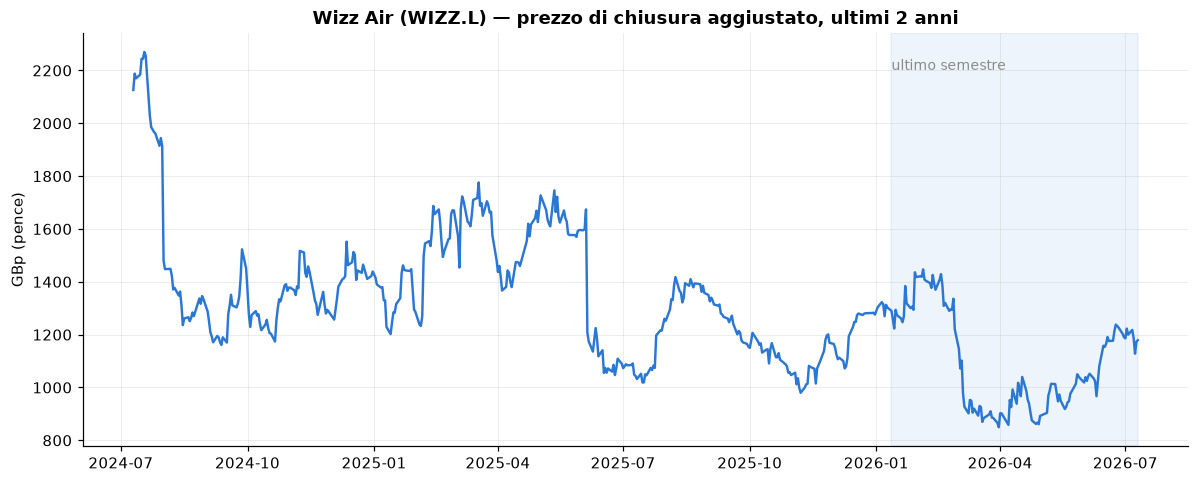

In [4]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(close.index, close['WIZZ'], color=COL['WIZZ'], lw=1.6)
ax.axvspan(SEM_START, close.index[-1], color=COL['WIZZ'], alpha=0.08)
ax.annotate('ultimo semestre', xy=(SEM_START, close['WIZZ'].max()*0.97),
            fontsize=9, color=GRAY, ha='left')
ax.set_title('Wizz Air (WIZZ.L) — prezzo di chiusura aggiustato, ultimi 2 anni')
ax.set_ylabel('GBp (pence)')
plt.tight_layout(); plt.show()

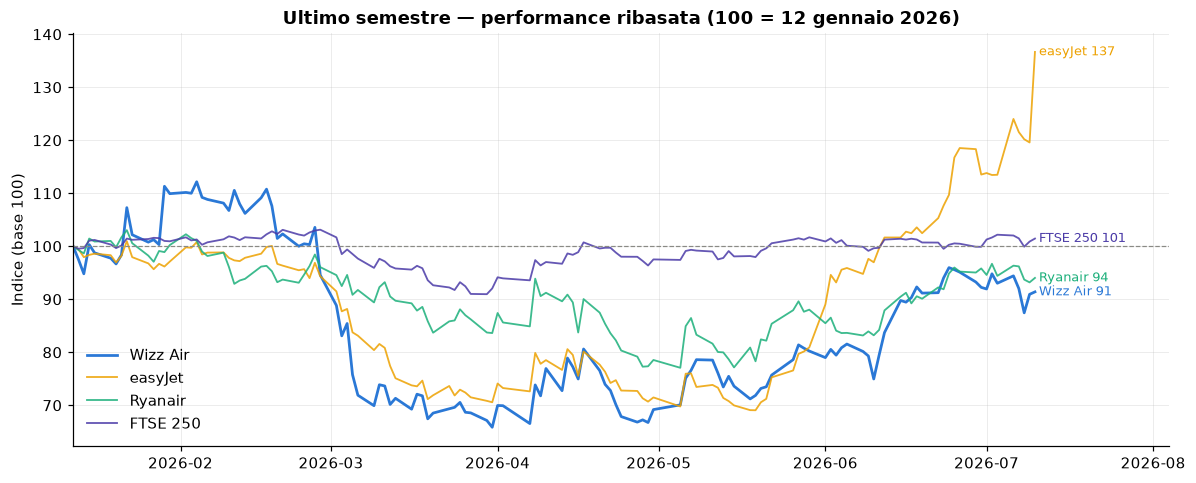

In [5]:
# Confronto ribasato a 100 all'inizio del semestre (rendimenti cumulati, valuta ininfluente)
base100 = close[close.index >= SEM_START]
base100 = base100 / base100.iloc[0] * 100
LBL = {'WIZZ': 'Wizz Air', 'EZJ': 'easyJet', 'RYA': 'Ryanair', 'FTSE250': 'FTSE 250'}

fig, ax = plt.subplots(figsize=(11, 4.5))
for k in ['WIZZ', 'EZJ', 'RYA', 'FTSE250']:
    ax.plot(base100.index, base100[k], color=COL[k], lw=1.8 if k == 'WIZZ' else 1.2,
            label=LBL[k], alpha=1.0 if k == 'WIZZ' else 0.85)
    ax.annotate(f' {LBL[k]} {base100[k].iloc[-1]:.0f}', xy=(base100.index[-1], base100[k].iloc[-1]),
                color=COL[k], fontsize=8.5, va='center')
ax.axhline(100, color=GRAY, lw=0.8, ls='--')
ax.set_title('Ultimo semestre — performance ribasata (100 = 12 gennaio 2026)')
ax.set_ylabel('Indice (base 100)'); ax.legend(loc='lower left', frameon=False)
ax.set_xlim(base100.index[0], base100.index[-1] + pd.Timedelta(days=25))
plt.tight_layout(); plt.show()

In [6]:
def perf_metrics(r, price):
    ann_ret = r.mean() * TRADING_DAYS
    ann_vol = r.std(ddof=1) * np.sqrt(TRADING_DAYS)
    downside = np.sqrt(TRADING_DAYS * np.mean(np.minimum(r - r.mean(), 0) ** 2))
    dd = price / price.cummax() - 1
    return {'Rend. totale semestre': np.exp(r.sum()) - 1,
            'Rend. annualizzato':    np.exp(ann_ret) - 1,
            'Volatilità ann.':       ann_vol,
            'Sharpe':                (ann_ret - RF_ANNUAL) / ann_vol,
            'Sortino':               (ann_ret - RF_ANNUAL) / downside,
            'Max drawdown':          dd.min(),
            'Skewness':              stats.skew(r),
            'Curtosi in eccesso':    stats.kurtosis(r)}

price_sem = close[close.index >= SEM_START]
perf = pd.DataFrame({LBL[k]: perf_metrics(ret_sem[k], price_sem[k]) for k in ret.columns}).T
fmt = perf.copy()
for col in ['Rend. totale semestre', 'Rend. annualizzato', 'Volatilità ann.', 'Max drawdown']:
    fmt[col] = (perf[col] * 100).round(1).astype(str) + '%'
for col in ['Sharpe', 'Sortino', 'Skewness', 'Curtosi in eccesso']:
    fmt[col] = perf[col].round(2)
print('METRICHE DI PERFORMANCE — ultimo semestre (12/01/2026 → 10/07/2026)\n')
print(fmt.to_string())

METRICHE DI PERFORMANCE — ultimo semestre (12/01/2026 → 10/07/2026)

         Rend. totale semestre Rend. annualizzato Volatilità ann.  Sharpe  Sortino Max drawdown  Skewness  Curtosi in eccesso
Wizz Air                 -9.5%             -18.3%           59.3%   -0.41    -0.61       -41.3%      0.25                0.84
easyJet                  33.8%              79.8%           47.9%    1.14     2.00       -31.6%      1.46                3.48
Ryanair                  -7.1%             -13.9%           40.2%   -0.47    -0.77       -25.2%      1.12                2.78
FTSE 250                  1.5%               2.9%           15.1%   -0.07    -0.11       -11.8%      0.40                2.39


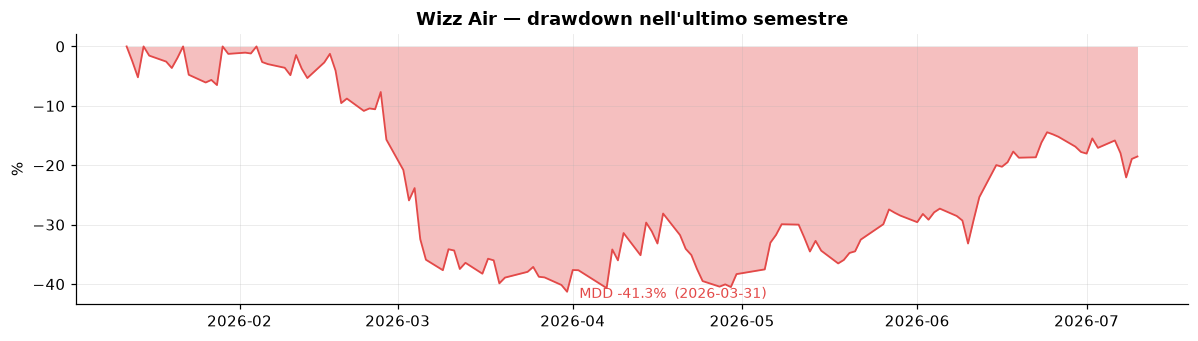

In [7]:
dd_wizz = price_sem['WIZZ'] / price_sem['WIZZ'].cummax() - 1
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.fill_between(dd_wizz.index, dd_wizz * 100, 0, color=NEG, alpha=0.35, lw=0)
ax.plot(dd_wizz.index, dd_wizz * 100, color=NEG, lw=1.2)
tmin = dd_wizz.idxmin()
ax.annotate(f'MDD {dd_wizz.min()*100:.1f}%  ({tmin.date()})', xy=(tmin, dd_wizz.min()*100),
            xytext=(8, -4), textcoords='offset points', fontsize=9, color=NEG)
ax.set_title('Wizz Air — drawdown nell\'ultimo semestre')
ax.set_ylabel('%')
plt.tight_layout(); plt.show()

## 4. Indici di bilancio (FY2024–FY2026, esercizio chiuso al 31 marzo)

Definizioni (valori di bilancio in EUR, fonte: financial statements Wizz Air via Yahoo Finance):

| Area | Indice | Formula |
|---|---|---|
| Redditività | ROE | $\text{Utile netto} / \text{Patrimonio netto}$ |
| Redditività | ROA | $\text{Utile netto} / \text{Totale attivo}$ |
| Redditività | Margine EBITDA | $\text{EBITDA} / \text{Ricavi}$ |
| Redditività | Margine operativo (ROS) | $\text{EBIT} / \text{Ricavi}$ |
| Redditività | Margine netto | $\text{Utile netto} / \text{Ricavi}$ |
| Liquidità | Current ratio | $\text{Attivo corrente} / \text{Passivo corrente}$ |
| Liquidità | Cash ratio | $\text{Cassa} / \text{Passivo corrente}$ |
| Solidità | Debt/Equity | $\text{Debito totale} / \text{Patrimonio netto}$ |
| Solidità | Interest coverage | $\text{EBIT} / \text{Oneri finanziari}$ |
| Solidità | Net debt / EBITDA | $(\text{Debito} - \text{Cassa}) / \text{EBITDA}$ |
| Efficienza | Asset turnover | $\text{Ricavi} / \text{Totale attivo}$ |

**Attenzione interpretativa**: il debito di Wizz Air include le **passività per leasing aeromobili** (IFRS 16) — la flotta è quasi interamente in leasing, quindi Debt/Equity e Net debt/EBITDA vanno letti in quest'ottica settoriale, non come debito bancario classico.

In [8]:
f = fund.T  # metriche in riga, esercizi in colonna
f.columns = [d.strftime('FY%Y') for d in fund.index]
f = f[['FY2024', 'FY2025', 'FY2026']]
g = lambda name: f.loc[name]

net_debt = g('annualTotalDebt') - g('annualCashAndCashEquivalents')   # FY2026 assente in fonte → calcolato

ratios = pd.DataFrame({
    'Ricavi (mln €)':        g('annualTotalRevenue') / 1e6,
    'Crescita ricavi':       g('annualTotalRevenue').pct_change(),
    'EBITDA (mln €)':        g('annualEBITDA') / 1e6,
    'Utile netto (mln €)':   g('annualNetIncome') / 1e6,
    'ROE':                   g('annualNetIncome') / g('annualStockholdersEquity'),
    'ROA':                   g('annualNetIncome') / g('annualTotalAssets'),
    'Margine EBITDA':        g('annualEBITDA') / g('annualTotalRevenue'),
    'Margine operativo':     g('annualOperatingIncome') / g('annualTotalRevenue'),
    'Margine netto':         g('annualNetIncome') / g('annualTotalRevenue'),
    'Current ratio':         g('annualCurrentAssets') / g('annualCurrentLiabilities'),
    'Cash ratio':            g('annualCashAndCashEquivalents') / g('annualCurrentLiabilities'),
    'Debt/Equity':           g('annualTotalDebt') / g('annualStockholdersEquity'),
    'Interest coverage':     g('annualOperatingIncome') / g('annualInterestExpense'),
    'Net debt/EBITDA':       net_debt / g('annualEBITDA'),
    'Asset turnover':        g('annualTotalRevenue') / g('annualTotalAssets'),
    'FCF (mln €)':           g('annualFreeCashFlow') / 1e6,
}).T

pct_rows = ['Crescita ricavi', 'ROE', 'ROA', 'Margine EBITDA', 'Margine operativo', 'Margine netto']
disp = pd.DataFrame({col: [(f'{v*100:.1f}%' if r_ in pct_rows else f'{v:,.2f}') if pd.notna(v) else '—'
                           for r_, v in ratios[col].items()]
                     for col in ratios.columns}, index=ratios.index)
print('INDICI DI BILANCIO WIZZ AIR — esercizi chiusi al 31 marzo\n')
print(disp.to_string())

INDICI DI BILANCIO WIZZ AIR — esercizi chiusi al 31 marzo

                       FY2024    FY2025    FY2026
Ricavi (mln €)       5,073.10  5,267.60  5,691.40
Crescita ricavi             —      3.8%      8.0%
EBITDA (mln €)       1,293.10  1,236.00  1,473.40
Utile netto (mln €)    376.60    225.80      2.20
ROE                    205.3%     61.6%      0.2%
ROA                      4.3%      2.3%      0.0%
Margine EBITDA          25.5%     23.5%     25.9%
Margine operativo        8.6%      3.2%      2.5%
Margine netto            7.4%      4.3%      0.0%
Current ratio            0.87      0.69      0.97
Cash ratio               0.24      0.16      0.31
Debt/Equity             34.19     18.04      7.49
Interest coverage        2.23      0.67      0.52
Net debt/EBITDA          4.29      4.87      4.00
Asset turnover           0.58      0.55      0.51
FCF (mln €)            -44.40    420.10    526.50


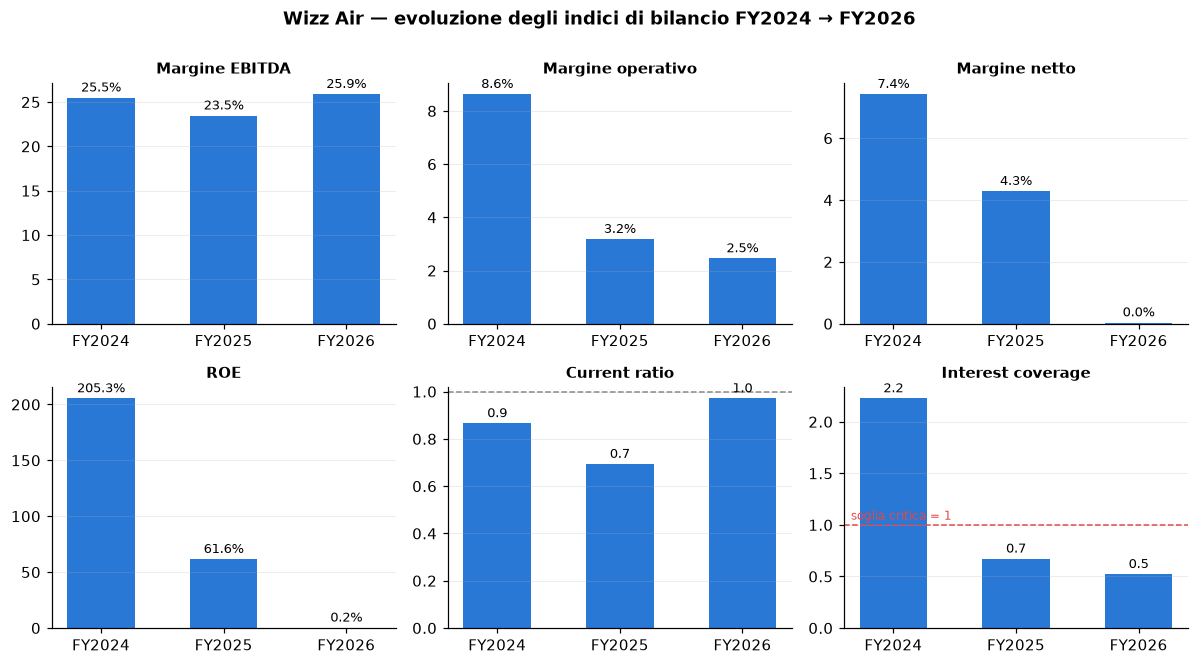

In [9]:
sel = {'Margine EBITDA': 'pct', 'Margine operativo': 'pct', 'Margine netto': 'pct',
       'ROE': 'pct', 'Current ratio': 'x', 'Interest coverage': 'x'}
fig, axes = plt.subplots(2, 3, figsize=(11, 6))
years = ratios.columns
for ax, (name, kind) in zip(axes.flat, sel.items()):
    vals = ratios.loc[name] * (100 if kind == 'pct' else 1)
    colors = [COL['WIZZ'] if v >= 0 else NEG for v in vals]
    bars = ax.bar(years, vals, color=colors, width=0.55)
    ax.bar_label(bars, fmt='%.1f' + ('%%' if kind == 'pct' else ''), fontsize=8.5, padding=2)
    if name == 'Interest coverage':
        ax.axhline(1, color=NEG, lw=1, ls='--')
        ax.annotate('soglia critica = 1', xy=(0.02, 1.05), xycoords=('axes fraction', 'data'),
                    fontsize=8, color=NEG)
    if name == 'Current ratio':
        ax.axhline(1, color=GRAY, lw=1, ls='--')
    ax.set_title(name, fontsize=10)
    ax.grid(axis='x')
fig.suptitle('Wizz Air — evoluzione degli indici di bilancio FY2024 → FY2026', fontweight='bold', y=1.0)
plt.tight_layout(); plt.show()

### 4.1 Lettura degli indici — la storia che raccontano

I numeri FY2026 (esercizio chiuso il 31/03/2026) descrivono un'azienda che **cresce ma non guadagna quasi nulla**:

- **Ricavi in crescita**: 5.073 → 5.268 → 5.691 mln € (+8,0% nell'ultimo esercizio). La domanda c'è, la capacità pure.
- **Redditività crollata**: l'utile netto passa da 376,6 mln € (FY2024) a 225,8 mln € (FY2025) a **2,2 mln € (FY2026)** — margine netto ≈ 0,04%. Il ROE scende da livelli estremi (205% su un equity post-COVID quasi azzerato di 183 mln €) allo **0,2%**.
- **Il problema è il costo del debito**: EBIT FY2026 = 139,7 mln € contro oneri finanziari = 267,8 mln € → **interest coverage = 0,52 < 1**: la gestione operativa non copre gli interessi (compensata a P&L da poste finanziarie non ricorrenti). È l'indice più critico dell'intero quadro.
- **Struttura finanziaria in miglioramento parziale**: il patrimonio netto risale a 932 mln € (aumento di capitale/utili trattenuti) e il Debt/Equity scende da 34x a **7,5x** — ancora altissimo, ma il debito è in gran parte **leasing IFRS 16 sulla flotta**, fisiologico per il modello ultra-low-cost.
- **Liquidità**: current ratio 0,97 e capitale circolante negativo — tipico delle compagnie aeree (i biglietti si incassano prima di erogare il servizio: il passivo corrente contiene ricavi differiti); la cassa raddoppia a 1.086 mln €.
- **Cash flow positivo**: FCF = 526,5 mln € nonostante l'utile ≈ 0 — la distanza tra utile contabile e cassa è spiegata da ammortamenti elevati (EBITDA 1.473 mln €, margine 25,9%, in *crescita*).

**Sintesi**: il conto economico soffre *sotto* l'EBITDA — leasing, interessi, carburante/motori (le note problematiche ai motori Pratt & Whitney GTF hanno tenuto a terra parte della flotta). Questo profilo — leva alta, utili sottili e volatili — è esattamente ciò che giustifica l'elevata volatilità e il beta > 1 che stimeremo nei paragrafi seguenti.

## 5. Modello della media condizionata: ARIMA

### 5.1 Stazionarietà — test ADF

Un modello ARMA richiede stazionarietà. Il test **Augmented Dickey–Fuller** verifica $H_0$: presenza di radice unitaria (serie non stazionaria). La teoria prevede prezzi $I(1)$ e log-rendimenti $I(0)$; l'esito va però letto criticamente sul campione effettivo (finestre corte con trend marcato possono distorcere il test sui livelli). In ogni caso la prassi consolidata — e la scelta qui — è modellare i **log-rendimenti** con ARIMA$(p,0,q)$ ≡ ARMA$(p,q)$.

In [10]:
for nome, serie in [('Prezzo WIZZ (livelli)', close['WIZZ']), ('Log-rendimenti WIZZ', r_wizz)]:
    stat, pval, *_ = adfuller(serie.dropna(), autolag='AIC')
    esito = 'RIFIUTO H0 → stazionaria' if pval < 0.05 else 'non rifiuto H0 → NON stazionaria'
    print(f'{nome:28s}  ADF = {stat:7.3f}   p-value = {pval:.4f}   → {esito}')

Prezzo WIZZ (livelli)         ADF =  -3.496   p-value = 0.0081   → RIFIUTO H0 → stazionaria
Log-rendimenti WIZZ           ADF = -22.184   p-value = 0.0000   → RIFIUTO H0 → stazionaria


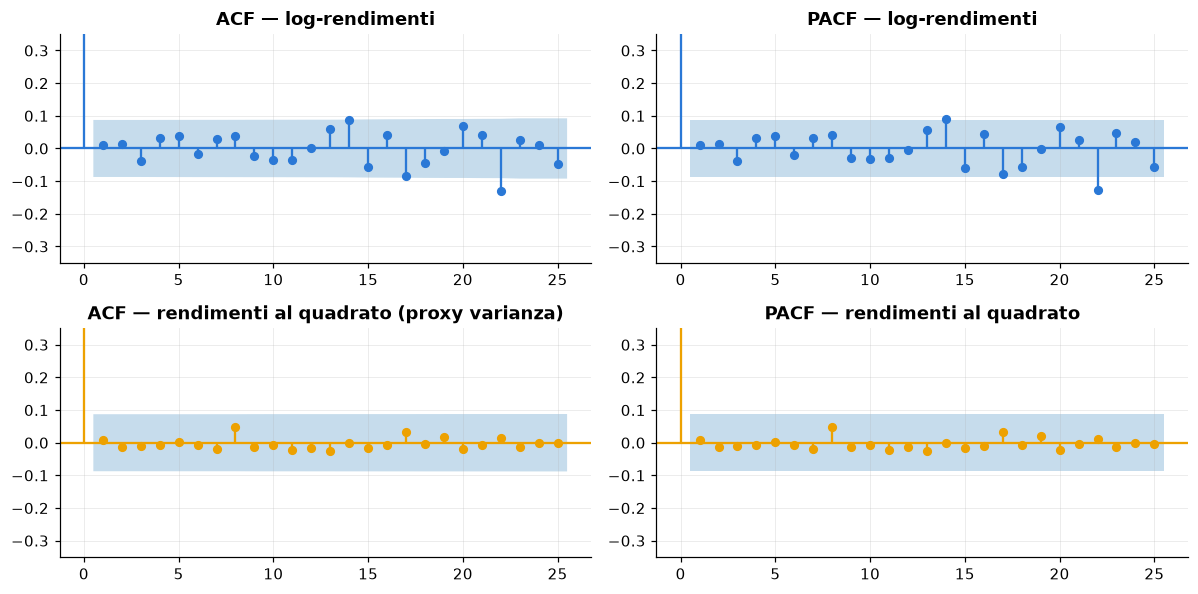

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(11, 5.5))
plot_acf(r_wizz, lags=25, ax=axes[0, 0], color=COL['WIZZ'], vlines_kwargs={'colors': COL['WIZZ']})
axes[0, 0].set_title('ACF — log-rendimenti')
plot_pacf(r_wizz, lags=25, ax=axes[0, 1], color=COL['WIZZ'], vlines_kwargs={'colors': COL['WIZZ']})
axes[0, 1].set_title('PACF — log-rendimenti')
plot_acf(r_wizz**2, lags=25, ax=axes[1, 0], color=COL['EZJ'], vlines_kwargs={'colors': COL['EZJ']})
axes[1, 0].set_title('ACF — rendimenti al quadrato (proxy varianza)')
plot_pacf(r_wizz**2, lags=25, ax=axes[1, 1], color=COL['EZJ'], vlines_kwargs={'colors': COL['EZJ']})
axes[1, 1].set_title('PACF — rendimenti al quadrato')
for ax in axes.flat: ax.set_ylim(-0.35, 0.35)
plt.tight_layout(); plt.show()

**Lettura dei test e dei correlogrammi** (esito sul campione effettivo, da leggere sopra):

- Sui **log-rendimenti** l'ADF rifiuta nettamente $H_0$ (p ≈ 0): stazionari, come atteso.
- Sui **prezzi** l'ADF rifiuta anch'esso $H_0$ (p < 0,01) — esito atipico: in una finestra di 2 anni con forte trend ribassista il test può scambiare il mean-reverting apparente per stazionarietà. Non cambia la scelta operativa (si modellano i rendimenti), ma è corretto segnalarlo invece di nasconderlo.
- L'autocorrelazione dei rendimenti è debole (mercato ~efficiente in media); quella dei **rendimenti al quadrato** è visibile solo su pochi ritardi: un primo indizio che il rischio di WIZZ in questo campione è fatto più di **salti isolati** (news su motori, utili) che di clustering persistente — ipotesi che il test ARCH-LM del § 6.1 verificherà formalmente.

### 5.2 Selezione ARIMA per criterio informativo

Si stima ARIMA$(p,0,q)$ per $p,q \in \{0,\dots,3\}$ sull'**intero campione di 2 anni** (504 osservazioni: stimare un GARCH su soli 126 punti darebbe stime inaffidabili; il semestre resta la finestra di *valutazione*). Selezione con **AIC** $= -2\ln L + 2k$, che penalizza la complessità.

In [12]:
results = []
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for p, q in itertools.product(range(4), range(4)):
        try:
            fit_ = ARIMA(r_wizz, order=(p, 0, q)).fit()
            results.append({'p': p, 'q': q, 'AIC': fit_.aic, 'BIC': fit_.bic})
        except Exception:
            pass
tab = pd.DataFrame(results).sort_values('AIC').reset_index(drop=True)
print('Top 5 per AIC:\n', tab.head(5).to_string(index=False))

p_best, q_best = int(tab.loc[0, 'p']), int(tab.loc[0, 'q'])
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    arima_fit = ARIMA(r_wizz, order=(p_best, 0, q_best)).fit()
print(f'\nModello selezionato: ARIMA({p_best},0,{q_best})   AIC = {arima_fit.aic:.1f}')

Top 5 per AIC:
  p  q          AIC          BIC
 0  0 -1866.498289 -1858.053137
 1  0 -1864.543976 -1851.876247
 0  1 -1864.542336 -1851.874607
 0  2 -1862.624127 -1845.733822
 2  0 -1862.620728 -1845.730423

Modello selezionato: ARIMA(0,0,0)   AIC = -1866.5


In [13]:
resid = arima_fit.resid.dropna()
lb = acorr_ljungbox(resid, lags=[10, 20], return_df=True)
jb_stat, jb_p = stats.jarque_bera(resid)[:2]
print('DIAGNOSTICA RESIDUI ARIMA')
print(f'  Ljung-Box lag 10: p = {lb["lb_pvalue"].iloc[0]:.3f}   lag 20: p = {lb["lb_pvalue"].iloc[1]:.3f}'
      f'   → {"nessuna autocorrelazione residua" if lb["lb_pvalue"].min() > 0.05 else "autocorrelazione residua presente"}')
print(f'  Jarque-Bera: stat = {jb_stat:.1f}, p = {jb_p:.2e} → residui NON gaussiani (code pesanti)')
print(f'  Skewness = {stats.skew(resid):.2f}   Curtosi in eccesso = {stats.kurtosis(resid):.2f}')
print('\n→ La media è ben specificata; le code pesantissime (curtosi ≈ 15) richiedono un modello per la varianza')
print('  e per la distribuzione delle innovazioni: § 6, GARCH con innovazioni t-Student.')

DIAGNOSTICA RESIDUI ARIMA
  Ljung-Box lag 10: p = 0.933   lag 20: p = 0.418   → nessuna autocorrelazione residua
  Jarque-Bera: stat = 5043.2, p = 0.00e+00 → residui NON gaussiani (code pesanti)
  Skewness = -1.45   Curtosi in eccesso = 15.22

→ La media è ben specificata; le code pesantissime (curtosi ≈ 15) richiedono un modello per la varianza
  e per la distribuzione delle innovazioni: § 6, GARCH con innovazioni t-Student.


## 6. Modello della varianza condizionata: GARCH

### 6.1 Test ARCH-LM

Prima di stimare un GARCH occorre verificare formalmente la presenza di **eteroschedasticità condizionata**. Il test **ARCH-LM** (Engle, 1982) regredisce $\hat\varepsilon_t^2$ sui propri ritardi; $H_0$: assenza di effetti ARCH.

In [14]:
lm_stat, lm_p, f_stat, f_p = het_arch(resid, nlags=10)
print(f'ARCH-LM (10 lag): LM = {lm_stat:.1f}, p-value = {lm_p:.2e}')
print('→ H0 rifiutata: effetti ARCH fortemente significativi, il GARCH è giustificato.'
      if lm_p < 0.05 else '→ H0 non rifiutata: attenzione, effetti ARCH deboli.')

ARCH-LM (10 lag): LM = 1.5, p-value = 9.99e-01
→ H0 non rifiutata: attenzione, effetti ARCH deboli.


**Lettura onesta dell'esito**: su questo campione l'ARCH-LM **non rifiuta** $H_0$ — gli effetti ARCH sono deboli. Combinato con la diagnostica del § 5 (curtosi in eccesso ≈ 15, skewness negativa, Jarque-Bera con p ≈ 0), il quadro è chiaro: il rischio di WIZZ in questi 2 anni è dominato da **salti isolati di grande ampiezza** (jump risk: profit warning, notizie sui motori Pratt & Whitney) più che da volatilità persistente e prevedibile. È un risultato, non un fallimento: dice che per questo titolo **le code pesanti contano più del clustering**. Si stima comunque il GARCH-t per tre ragioni: (i) la t-Student cattura esattamente le code pesanti osservate; (ii) il confronto GARCH vs GJR quantifica *quanto* poca persistenza c'è; (iii) fornisce il quantile condizionato per il VaR del § 7, la cui qualità verrà giudicata dal backtest — il vero arbitro.

### 6.2 Specifica e stima

**GARCH(1,1)** con innovazioni t-Student (code pesanti):

$$r_t = \mu + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \quad z_t \sim t_\nu \qquad
\sigma_t^2 = \omega + \alpha\,\varepsilon_{t-1}^2 + \beta\,\sigma_{t-1}^2$$

**GJR-GARCH(1,1)** aggiunge l'**effetto leva** (le cattive notizie aumentano la volatilità più delle buone):

$$\sigma_t^2 = \omega + (\alpha + \gamma\,\mathbb{1}_{\{\varepsilon_{t-1}<0\}})\,\varepsilon_{t-1}^2 + \beta\,\sigma_{t-1}^2$$

Statistiche chiave: **persistenza** $\alpha + \beta$ (nel GJR: $\alpha + \gamma/2 + \beta$) e **half-life** degli shock $HL = \ln(0.5)/\ln(\alpha+\beta)$. I rendimenti sono scalati ×100 per la stabilità numerica dell'ottimizzatore.

**Criterio di scelta**: tra i due modelli si seleziona per **BIC** ($-2\ln L + k\ln T$), più severo dell'AIC sulla complessità: con effetti ARCH deboli (come segnalato dall'ARCH-LM sopra) il rischio concreto è premiare un parametro in più ($\gamma$) che non è statisticamente significativo o produce stime degeneri. La significatività di $\gamma$ viene comunque verificata e riportata.

In [15]:
r100 = r_wizz * 100

am_g   = arch_model(r100, mean='Constant', vol='GARCH', p=1, q=1, dist='t')
am_gjr = arch_model(r100, mean='Constant', vol='GARCH', p=1, o=1, q=1, dist='t')
res_g, res_gjr = am_g.fit(disp='off'), am_gjr.fit(disp='off')

def garch_row(res, gjr=False):
    pr = res.params
    pers = pr['alpha[1]'] + pr['beta[1]'] + (pr.get('gamma[1]', 0) / 2 if gjr else 0)
    return {'ω': pr['omega'], 'α': pr['alpha[1]'], 'γ (leva)': pr.get('gamma[1]', np.nan),
            'β': pr['beta[1]'], 'ν (gdl t)': pr['nu'], 'Persistenza': pers,
            'Half-life (gg)': np.log(0.5) / np.log(pers), 'AIC': res.aic, 'BIC': res.bic,
            'Convergenza': res.convergence_flag == 0}

cmp = pd.DataFrame({'GARCH(1,1)-t': garch_row(res_g), 'GJR-GARCH(1,1)-t': garch_row(res_gjr, gjr=True)}).T
print(cmp.round(3).to_string())

best_name = cmp['BIC'].idxmin()
res_best = res_gjr if best_name.startswith('GJR') else res_g
gamma_p = res_gjr.pvalues.get('gamma[1]', np.nan)
print(f'\nModello selezionato per BIC: {best_name}')
print(f'Verifica effetto leva: γ del GJR = {res_gjr.params.get("gamma[1]", np.nan):.3f} '
      f'(p-value = {gamma_p:.3f}) → {"significativo" if gamma_p < 0.05 else "NON significativo: il GJR non è supportato dai dati"}')
if res_gjr.params.get('beta[1]', 1) < 1e-4:
    print('Nota: nel GJR la stima β ≈ 0 è degenere (perdita della memoria GARCH) — ulteriore ragione per preferire il GARCH(1,1).')
assert res_best.convergence_flag == 0, 'ottimizzazione non convergiuta!'

                          ω         α  γ (leva)         β ν (gdl t) Persistenza Half-life (gg)          AIC          BIC Convergenza
GARCH(1,1)-t        3.78792  0.107352       NaN  0.650647  3.253839    0.757999       2.501676  2630.013729  2651.126611        True
GJR-GARCH(1,1)-t  11.279604  0.142858  0.286041       0.0  3.412302    0.285879       0.553549  2628.894771  2654.230228        True

Modello selezionato per BIC: GARCH(1,1)-t
Verifica effetto leva: γ del GJR = 0.286 (p-value = 0.194) → NON significativo: il GJR non è supportato dai dati
Nota: nel GJR la stima β ≈ 0 è degenere (perdita della memoria GARCH) — ulteriore ragione per preferire il GARCH(1,1).


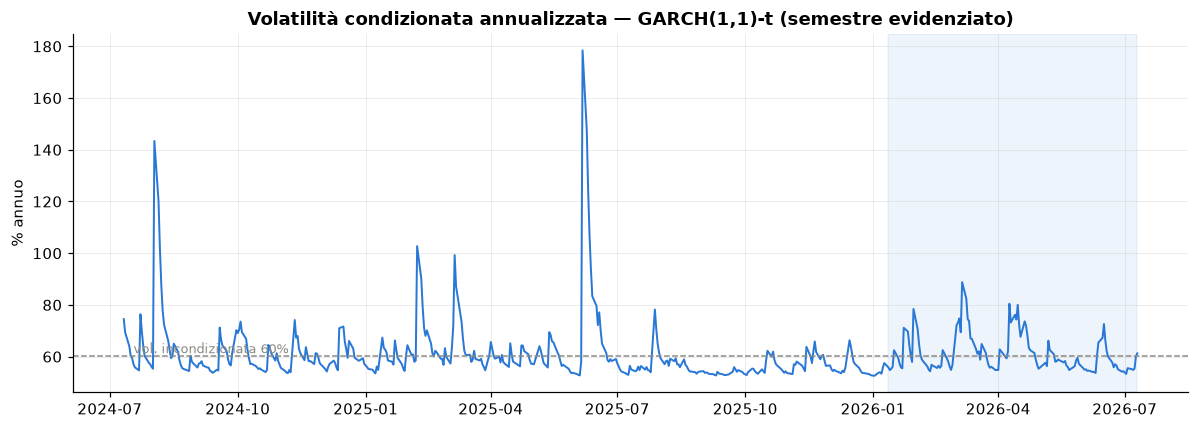

In [16]:
vol_ann = res_best.conditional_volatility / 100 * np.sqrt(TRADING_DAYS) * 100  # % annualizzata
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(vol_ann.index, vol_ann, color=COL['WIZZ'], lw=1.3)
ax.axvspan(SEM_START, vol_ann.index[-1], color=COL['WIZZ'], alpha=0.08)
uncond = float(np.sqrt(r100.var()) / 100 * np.sqrt(TRADING_DAYS) * 100)
ax.axhline(uncond, color=GRAY, ls='--', lw=1)
ax.annotate(f'vol. incondizionata {uncond:.0f}%', xy=(vol_ann.index[5], uncond), fontsize=8.5,
            color=GRAY, va='bottom')
ax.set_title(f'Volatilità condizionata annualizzata — {best_name} (semestre evidenziato)')
ax.set_ylabel('% annuo')
plt.tight_layout(); plt.show()

## 7. Value-at-Risk e Expected Shortfall, con backtest

### 7.1 Definizioni

Il **VaR** a livello $\alpha$ e orizzonte 1 giorno è la perdita che non viene superata con probabilità $\alpha$:

$$\text{VaR}_\alpha = -\inf\{x : F_r(x) \ge 1-\alpha\}$$

L'**Expected Shortfall (CVaR)** è la perdita media *condizionata* all'aver superato il VaR — coerente come misura di rischio (subadditiva), a differenza del VaR:

$$\text{ES}_\alpha = -\,\mathbb{E}\!\left[r \mid r \le -\text{VaR}_\alpha\right]$$

Quattro approcci a confronto: **parametrico normale**, **parametrico t-Student**, **storico** (quantile empirico, 1 anno), **GARCH** (volatilità condizionata del giorno × quantile della t standardizzata).

### 7.2 Disegno del backtest — senza look-ahead

I parametri del GARCH sono stimati **solo sui dati precedenti al semestre** (train: luglio 2024 → gennaio 2026); il modello viene poi *filtrato* sull'intero campione a parametri fissi. Poiché $\sigma_t^2$ dipende solo dall'informazione fino a $t-1$, il $\text{VaR}_t$ così costruito è una vera previsione out-of-sample per ogni giorno del semestre.

Il **test di Kupiec (1995, unconditional coverage)** verifica se la frequenza di violazioni osservata $x/T$ è compatibile con quella attesa $1-\alpha$:

$$LR_{POF} = -2\ln\frac{(1-p)^{T-x} p^{x}}{\left(1-\frac{x}{T}\right)^{T-x} \left(\frac{x}{T}\right)^{x}} \;\sim\; \chi^2_1 \quad \text{sotto } H_0,\ p = 1-\alpha$$

In [17]:
# VaR/ES "di oggi" (fine campione), 1 giorno, per α = 95% e 99%
alphas = [0.95, 0.99]
mu_d, sd_d = r_wizz.mean(), r_wizz.std(ddof=1)
nu_hat = res_best.params['nu']
t_scale = np.sqrt((nu_hat - 2) / nu_hat)                    # rende unitaria la varianza della t
sigma_today = float(res_best.conditional_volatility.iloc[-1]) / 100
hist_1y = r_wizz.iloc[-TRADING_DAYS:]

rows = {}
for a in alphas:
    z, tq = stats.norm.ppf(1 - a), stats.t.ppf(1 - a, nu_hat)
    es_z = stats.norm.pdf(z) / (1 - a)                       # ES normale in unità di σ
    var_hist = -np.quantile(hist_1y, 1 - a)
    es_hist = -hist_1y[hist_1y <= np.quantile(hist_1y, 1 - a)].mean()
    rows[f'{a:.0%}'] = {
        'Normale':      -(mu_d + z * sd_d),
        't-Student':    -(mu_d + tq * t_scale * sd_d),
        'Storico (1a)': var_hist,
        'GARCH':        -(mu_d + tq * t_scale * sigma_today),
        'ES storico':   es_hist,
        'ES normale':   -mu_d + es_z * sd_d,
    }
var_tab = pd.DataFrame(rows).T * 100
print('VaR / ES a 1 giorno (in % del capitale), stimati a fine campione:\n')
print(var_tab.round(2).to_string())
print(f'\nσ condizionata GARCH di oggi = {sigma_today*100:.2f}% giorno  vs  σ incondizionata = {sd_d*100:.2f}%')

VaR / ES a 1 giorno (in % del capitale), stimati a fine campione:

     Normale  t-Student  Storico (1a)  GARCH  ES storico  ES normale
95%     6.35       5.48          4.91   5.58        6.40        7.93
99%     8.93      10.15          6.46  10.34        9.25       10.21

σ condizionata GARCH di oggi = 3.86% giorno  vs  σ incondizionata = 3.79%


In [18]:
# ── Backtest out-of-sample sull'ultimo semestre ──────────────────────────────
train = r100[r100.index < SEM_START]
o_best = 1 if best_name.startswith('GJR') else 0          # stessa specifica scelta al § 6.2
am_bt = arch_model(train, mean='Constant', vol='GARCH', p=1, o=o_best, q=1, dist='t')
res_train = am_bt.fit(disp='off')
assert res_train.convergence_flag == 0

# filtro a parametri fissi sull'intero campione (σ_t dipende solo da info fino a t-1 → no look-ahead)
am_full = arch_model(r100, mean='Constant', vol='GARCH', p=1, o=o_best, q=1, dist='t')
res_fixed = am_full.fix(res_train.params.values)
sigma_all = res_fixed.conditional_volatility / 100
mu_tr = res_train.params['mu'] / 100
nu_tr = res_train.params['nu']
scale_tr = np.sqrt((nu_tr - 2) / nu_tr)

sigma_sem = sigma_all[sigma_all.index >= SEM_START]
r_bt = r_wizz[r_wizz.index >= SEM_START]

def kupiec(x, T, p):
    if x == 0:
        lr = -2 * (T * np.log(1 - p))
    else:
        lr = -2 * ((T - x) * np.log(1 - p) + x * np.log(p)
                   - (T - x) * np.log(1 - x / T) - x * np.log(x / T))
    return lr, 1 - stats.chi2.cdf(lr, df=1)

print('BACKTEST VaR — ultimo semestre, GARCH stimato solo su dati pre-semestre\n')
var_series = {}
bt_rows = []
for a in alphas:
    tq = stats.t.ppf(1 - a, nu_tr)
    v = -(mu_tr + tq * scale_tr * sigma_sem)          # VaR_t (positivo = perdita)
    var_series[a] = v
    viol = (r_bt < -v).sum()
    T = len(r_bt)
    lr, pv = kupiec(viol, T, 1 - a)
    bt_rows.append({'α': f'{a:.0%}', 'Attese': round(T * (1 - a), 1), 'Osservate': int(viol),
                    'LR Kupiec': round(lr, 2), 'p-value': round(pv, 3),
                    'Esito': 'OK (calibrato)' if pv > 0.05 else 'RIFIUTATO'})
print(pd.DataFrame(bt_rows).to_string(index=False))

BACKTEST VaR — ultimo semestre, GARCH stimato solo su dati pre-semestre

  α  Attese  Osservate  LR Kupiec  p-value          Esito
95%     6.3          8       0.48    0.490 OK (calibrato)
99%     1.3          1       0.05    0.816 OK (calibrato)


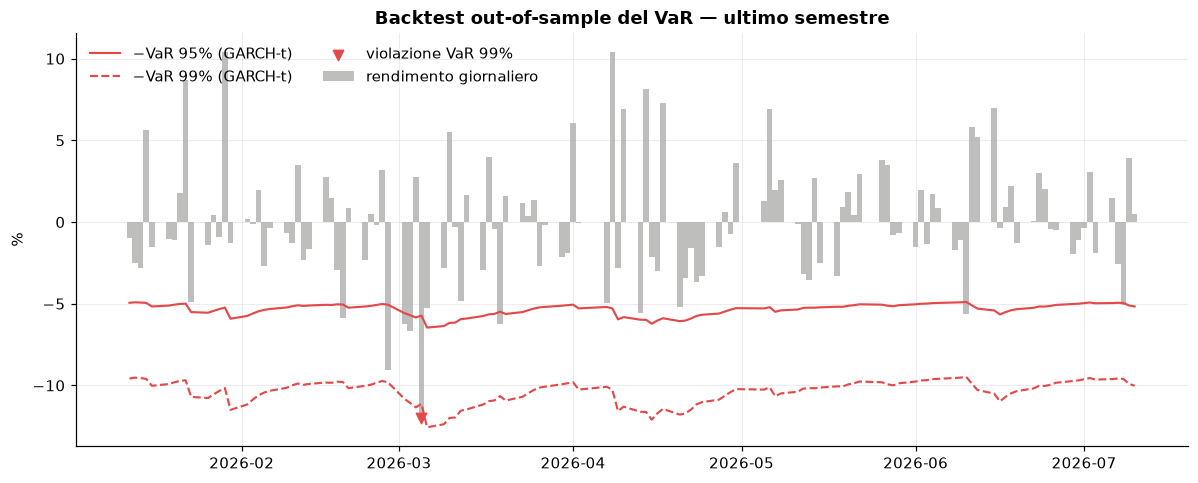

In [19]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(r_bt.index, r_bt * 100, color=GRAY, alpha=0.55, width=1.0, label='rendimento giornaliero')
for a, ls in zip(alphas, ['-', '--']):
    ax.plot(var_series[a].index, -var_series[a] * 100, color=NEG, ls=ls, lw=1.4, label=f'−VaR {a:.0%} (GARCH-t)')
viol_mask = r_bt < -var_series[0.99]
ax.scatter(r_bt.index[viol_mask], r_bt[viol_mask] * 100, color=NEG, zorder=5, s=45,
           marker='v', label='violazione VaR 99%')
ax.set_title('Backtest out-of-sample del VaR — ultimo semestre')
ax.set_ylabel('%'); ax.legend(loc='upper left', frameon=False, ncols=2)
plt.tight_layout(); plt.show()

## 8. Rischio sistematico: beta CAPM

Regressione OLS dei rendimenti in eccesso di WIZZ sul mercato (FTSE 250, stessa piazza di quotazione):

$$r_{WIZZ,t} - r_f = \alpha + \beta\,(r_{M,t} - r_f) + \epsilon_t$$

con errori standard robusti HAC (Newey–West). $\beta > 1$ ⇒ il titolo amplifica i movimenti del mercato.

Campione 2 anni        β =  1.65  (t = 6.7)   α ann. =  -36.0%  (p = 0.37)   R² = 0.14
Ultimo semestre        β =  2.44  (t = 9.4)   α ann. =  -21.5%  (p = 0.74)   R² = 0.38


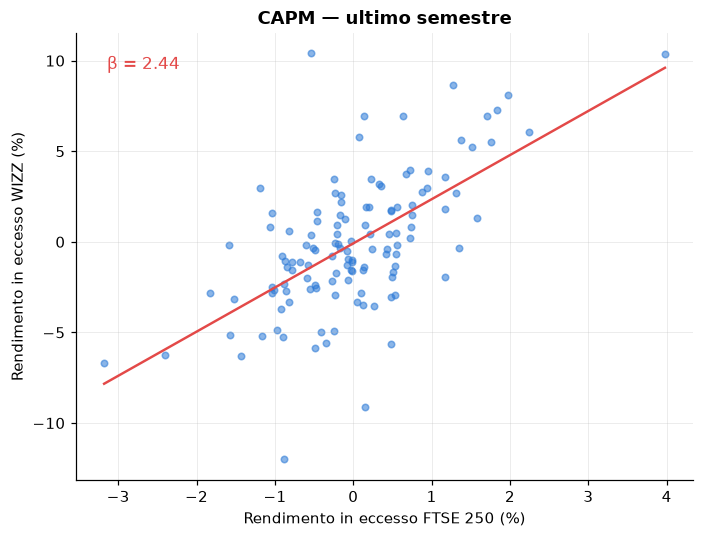

In [20]:
rf_d = RF_ANNUAL / TRADING_DAYS
ex = ret[['WIZZ', 'FTSE250']].dropna() - rf_d

def capm(df, label):
    X = sm.add_constant(df['FTSE250'])
    ols = sm.OLS(df['WIZZ'], X).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
    a_ann = ols.params['const'] * TRADING_DAYS
    print(f'{label:22s} β = {ols.params["FTSE250"]:5.2f}  (t = {ols.tvalues["FTSE250"]:.1f})   '
          f'α ann. = {a_ann*100:6.1f}%  (p = {ols.pvalues["const"]:.2f})   R² = {ols.rsquared:.2f}')
    return ols

ols_full = capm(ex, 'Campione 2 anni')
ols_sem  = capm(ex[ex.index >= SEM_START], 'Ultimo semestre')

fig, ax = plt.subplots(figsize=(6.5, 5))
sub = ex[ex.index >= SEM_START]
ax.scatter(sub['FTSE250'] * 100, sub['WIZZ'] * 100, s=18, color=COL['WIZZ'], alpha=0.55)
xx = np.linspace(sub['FTSE250'].min(), sub['FTSE250'].max(), 50)
ax.plot(xx * 100, (ols_sem.params['const'] + ols_sem.params['FTSE250'] * xx) * 100,
        color=NEG, lw=1.6)
ax.annotate(f'β = {ols_sem.params["FTSE250"]:.2f}', xy=(0.05, 0.92), xycoords='axes fraction',
            fontsize=11, color=NEG)
ax.set_xlabel('Rendimento in eccesso FTSE 250 (%)'); ax.set_ylabel('Rendimento in eccesso WIZZ (%)')
ax.set_title('CAPM — ultimo semestre')
plt.tight_layout(); plt.show()

## 9. Conclusioni

**Quadro fondamentale (FY2026).** Wizz Air cresce sui ricavi (+8,0%, a 5,69 mld €) ma la redditività è evaporata: utile netto 2,2 mln €, margine netto ≈ 0, **interest coverage 0,52** — la gestione operativa non copre gli oneri finanziari. La struttura è ad alta leva (D/E 7,5x, dominato dal leasing flotta IFRS 16), mitigata da cassa in crescita (1,09 mld €) e FCF positivo (527 mln €). Il profilo di rischio fondamentale è quindi *elevato e asimmetrico*: piccole variazioni operative si amplificano sull'utile.

**Performance di mercato (ultimo semestre).** Il titolo ha perso il **9,5%** con volatilità annualizzata del **59%** (quasi 4× il FTSE 250, al 15%) e un **max drawdown del −41%**. Il confronto settoriale è eloquente: nello stesso semestre easyJet ha guadagnato il **+33,8%** e Ryanair ha perso solo il 7,1% → la sottoperformance di Wizz Air è in larga parte **idiosincratica**, non di settore — coerente con i problemi specifici (leva, motori GTF) letti in bilancio.

**Rischio sistematico.** Il beta CAPM è **1,65** sui 2 anni e sale a **2,44 nell'ultimo semestre** (R² = 0,38, t = 9,4): Wizz Air amplifica i movimenti del mercato di quasi 2,5 volte. Alfa negativo ma non significativo.

**Modello statistico — cosa dicono davvero i dati.** La media dei log-rendimenti non è prevedibile (l'AIC seleziona ARIMA(0,0,0): white noise — coerente con l'efficienza in media). La sorpresa è sulla varianza: l'**ARCH-LM non rifiuta** $H_0$ e la persistenza GARCH stimata è moderata (α+β ≈ 0,76, half-life ≈ 2,5 giorni), mentre la curtosi in eccesso è ≈ 15 con ν della t-Student ≈ 3,3. Tradotto: il rischio di Wizz Air in questo campione **non è volatilità persistente ma jump risk** — salti isolati di grande ampiezza legati alle notizie societarie. Le code pesanti contano più del clustering.

**VaR — l'arbitro finale.** Il VaR GARCH-t out-of-sample (parametri stimati solo su dati pre-semestre, nessun look-ahead) supera il **test di Kupiec a entrambi i livelli**: 8 violazioni contro 6,3 attese al 95% (p = 0,49) e 1 contro 1,3 al 99% (p = 0,82). Nonostante gli effetti ARCH deboli, il quantile della t-Student calibra correttamente la coda — conferma che il modello di distribuzione era la scelta giusta.

**Limiti dichiarati** (onestà metodologica):
1. il backtest copre **un solo semestre** (~126 osservazioni): il test di Kupiec al 99% ha bassa potenza con così pochi giorni;
2. il tasso risk-free è assunto costante al 4%;
3. i bilanci sono **annuali** (Wizz Air non pubblica trimestrali complete su questa fonte): il collegamento fondamentali→prezzo è qualitativo, non una regressione panel;
4. quotazioni in GBp e bilancio in EUR: irrilevante per rendimenti e ratios (adimensionali), ma da ricordare per valutazioni assolute;
5. nessun regime-switching: eventi discreti (problemi motori GTF, shock petrolio) entrano solo attraverso la volatilità.

**Possibili estensioni**: EGARCH, VaR con simulazione Monte Carlo dalla t asimmetrica, test di Christoffersen (independence), modello multifattoriale (petrolio, EURHUF), confronto strutturato con Ryanair/easyJet sui fondamentali.